In [1]:
import numpy as np
import copy
import logging
import matplotlib.pyplot as plt

from tqdm import tqdm
from beartype import beartype
from scipy.spatial.distance import cdist

import UQpy
from UQpy.distributions import Normal, Uniform, JointIndependent
from UQpy.surrogates import polynomial_chaos
from UQpy.surrogates.polynomial_chaos import PolynomialChaosExpansion
from UQpy.surrogates.polynomial_chaos.regressions import LeastSquareRegression
from UQpy.surrogates.polynomial_chaos.polynomials.TotalDegreeBasis import TotalDegreeBasis

from Theta import ThetaCriterionPCE
from LAR import LeastAngleRegression

In [2]:
## Input data

Q = np.load("TEST_XY.npz")
X = Q["X"]
Y = Q["Y"]
X = np.asarray(X, dtype=float)
Y = np.asarray(Y, dtype=float)


## Variance_Ref

mask_var = np.all(np.isfinite(Y), axis=1)
Y_var_ref = Y[mask_var]

if Y_var_ref.shape[0] == 0:
    raise ValueError("No finite rows found in Y for variance reference.")

var_true_global = np.var(Y_var_ref, axis=0, ddof=1)

In [3]:
# Polynomial setting
dist1 = Normal(loc=25, scale=2.5)

# standardized normals (correspond to the two Weibull variables, but now X is already projected into Normal(0,1))
dist2 = Normal(loc=0, scale=1)
dist3 = Normal(loc=0, scale=1)

mi_4, sigma_4 = 90, 9
a_4, b_4 = mi_4 - sigma_4 / np.sqrt(2), mi_4 + sigma_4 / np.sqrt(2)
dist4 = Uniform(loc=a_4, scale=b_4 - a_4)

mi_5, sigma_5 = 30, 3
a_5, b_5 = mi_5 - sigma_5 / np.sqrt(2), mi_5 + sigma_5 / np.sqrt(2)
dist5 = Uniform(loc=a_5, scale=b_5 - a_5)

joint = JointIndependent([dist1, dist2, dist3, dist4, dist5])

P = 8
polynomial_basis = TotalDegreeBasis(joint, P, hyperbolic=0.6)

In [4]:
## Metrics for evaluation

# LOO error
def fit_pce_models(X_train, Y_train, polynomial_basis):
    nout = Y_train.shape[1]
    pce_models = []
    loo_err = np.full((nout,), np.nan, dtype=float)

    for j in range(nout):
        yj = Y_train[:, j]
        mask = np.isfinite(yj)

        if np.count_nonzero(mask) < 2:
            pce_models.append(None)
            continue

        p = PolynomialChaosExpansion(
            polynomial_basis=polynomial_basis,
            regression_method=LeastSquareRegression()
        )
        p.fit(X_train[mask], yj[mask])

        try:
            pLAR = LeastAngleRegression.model_selection(p)
        except Exception:
            pLAR = p

        pce_models.append(pLAR)

        try:
            loo_err[j] = float(pLAR.leaveoneout_error())
        except Exception:
            loo_err[j] = np.nan

    return pce_models, loo_err


# Prediction
def predict_all_outputs(pce_models, X_test):
    cols = []
    for p in pce_models:
        if p is None:
            cols.append(np.full((X_test.shape[0],), np.nan))
        else:
            cols.append(np.asarray(p.predict(X_test)).reshape(-1))
    return np.column_stack(cols)


# MAE & max AE
def compute_metrics_from_prediction(Y_true, Y_pred):
    abs_err = np.abs(Y_true - Y_pred)

    mae_per = np.mean(abs_err, axis=0)
    max_ae_per = np.max(abs_err, axis=0)

    return mae_per, max_ae_per


# Variance (compared to Var_ref later)
def compute_variance_from_models(pce_models, var_true):
    var_pce = []

    for p in pce_models:
        if p is None:
            var_pce.append(np.nan)
            continue

        try:
            _, v = p.get_moments()
        except Exception:
            v = np.nan

        var_pce.append(v)

    var_pce = np.asarray(var_pce, dtype=float)
    eps_per = np.abs(var_pce)

    return eps_per, var_pce

In [5]:
## Single experiment

def run_one_comparison(
    X,
    Y,
    polynomial_basis,
    init_n=10,
    naddedsims=200,
    batch_size=10,
    test_size=200,
    seed=2026,
    test_idx=None,
    var_true=None,
    candidate_pool_size=10000,
):

    X = np.asarray(X, dtype=float)
    Y = np.asarray(Y, dtype=float)

    if var_true is None:
        mask_var = np.all(np.isfinite(Y), axis=1)
        Y_var_ref = Y[mask_var]

        if Y_var_ref.shape[0] == 0:
            raise ValueError("No finite rows found in Y for variance reference.")

        var_true = np.var(Y_var_ref, axis=0, ddof=1)

    else:
        var_true = np.asarray(var_true, dtype=float)

    N = X.shape[0]

    rng = np.random.default_rng(seed)
    all_idx = np.arange(N)

    if test_idx is None:
        test_idx = rng.choice(
            all_idx,
            size=test_size,
            replace=False
        )
    else:
        test_idx = np.asarray(test_idx, dtype=int)

    usable_idx = np.setdiff1d(
        all_idx,
        test_idx,
        assume_unique=False
    )

    init_idx = rng.choice(
        usable_idx,
        size=init_n,
        replace=False
    )

    pool_all_idx = np.setdiff1d(
        usable_idx,
        init_idx,
        assume_unique=False
    )

    if candidate_pool_size is not None and len(pool_all_idx) > candidate_pool_size:
        pool_idx0 = rng.choice(
            pool_all_idx,
            size=candidate_pool_size,
            replace=False
        )
    else:
        pool_idx0 = pool_all_idx.copy()

    # Theta
    X_test = X[test_idx]
    Y_test = Y[test_idx]

    theta_pool_idx = pool_idx0.copy()

    X_theta = X[init_idx].copy()
    Y_theta = Y[init_idx].copy()

    theta_models, theta_loo = fit_pce_models(
        X_theta,
        Y_theta,
        polynomial_basis
    )

    theta_hist_eval = []
    theta_mae_hist = []
    theta_max_ae_hist = []
    theta_eps_hist = []
    theta_loo_hist = []

    total_to_add = min(
        int(naddedsims),
        len(theta_pool_idx)
    )

    for t in range(0, total_to_add, batch_size):

        n_pick = min(
            batch_size,
            total_to_add - t
        )

        if len(theta_pool_idx) == 0:
            break

        valid_models = [
            p for p in theta_models
            if p is not None
        ]

        if len(valid_models) == 0:
            break

        X_pool = X[theta_pool_idx]

        theta_sampler = ThetaCriterionPCE(valid_models)

        pos_local = theta_sampler.run(
            existing_samples=X_theta,
            candidate_samples=X_pool,
            nsamples=n_pick
        )

        pos_local = np.asarray(pos_local, dtype=int)
        pos_local = np.unique(pos_local)

        selected_idx = theta_pool_idx[pos_local]

        X_new = X[selected_idx]
        Y_new = Y[selected_idx]

        valid_rows = np.all(
            np.isfinite(Y_new),
            axis=1
        )

        if np.count_nonzero(valid_rows) == 0:
            theta_pool_idx = np.setdiff1d(
                theta_pool_idx,
                selected_idx,
                assume_unique=False
            )
            continue

        X_new = X_new[valid_rows]
        Y_new = Y_new[valid_rows]
        selected_idx = selected_idx[valid_rows]

        X_theta = np.vstack([
            X_theta,
            X_new
        ])

        Y_theta = np.vstack([
            Y_theta,
            Y_new
        ])

        theta_pool_idx = np.setdiff1d(
            theta_pool_idx,
            selected_idx,
            assume_unique=False
        )

        theta_models, theta_loo = fit_pce_models(
            X_theta,
            Y_theta,
            polynomial_basis
        )

        theta_pred = predict_all_outputs(
            theta_models,
            X_test
        )

        theta_mae, theta_max_ae = compute_metrics_from_prediction(
            Y_test,
            theta_pred
        )

        theta_eps, _ = compute_variance_from_models(
            theta_models,
            var_true
        )

        theta_hist_eval.append(X_theta.shape[0])
        theta_mae_hist.append(theta_mae)
        theta_max_ae_hist.append(theta_max_ae)
        theta_eps_hist.append(theta_eps)
        theta_loo_hist.append(theta_loo)

    # Reference
    lhs_pool_idx = pool_idx0.copy()

    X_lhs = X[init_idx].copy()
    Y_lhs = Y[init_idx].copy()

    lhs_hist_eval = []
    lhs_mae_hist = []
    lhs_max_ae_hist = []
    lhs_eps_hist = []
    lhs_loo_hist = []

    total_to_add = min(
        int(naddedsims),
        len(lhs_pool_idx)
    )

    for t in range(0, total_to_add, batch_size):

        n_pick = min(
            batch_size,
            total_to_add - t
        )

        if len(lhs_pool_idx) == 0:
            break

        selected_idx = rng.choice(
            lhs_pool_idx,
            size=n_pick,
            replace=False
        )

        X_new = X[selected_idx]
        Y_new = Y[selected_idx]

        valid_rows = np.all(
            np.isfinite(Y_new),
            axis=1
        )

        if np.count_nonzero(valid_rows) == 0:
            lhs_pool_idx = np.setdiff1d(
                lhs_pool_idx,
                selected_idx,
                assume_unique=False
            )
            continue

        X_new = X_new[valid_rows]
        Y_new = Y_new[valid_rows]
        selected_idx = selected_idx[valid_rows]

        X_lhs = np.vstack([
            X_lhs,
            X_new
        ])

        Y_lhs = np.vstack([
            Y_lhs,
            Y_new
        ])

        lhs_pool_idx = np.setdiff1d(
            lhs_pool_idx,
            selected_idx,
            assume_unique=False
        )

        lhs_models, lhs_loo = fit_pce_models(
            X_lhs,
            Y_lhs,
            polynomial_basis
        )

        lhs_pred = predict_all_outputs(
            lhs_models,
            X_test
        )

        lhs_mae, lhs_max_ae = compute_metrics_from_prediction(
            Y_test,
            lhs_pred
        )

        lhs_eps, _ = compute_variance_from_models(
            lhs_models,
            var_true
        )

        lhs_hist_eval.append(X_lhs.shape[0])
        lhs_mae_hist.append(lhs_mae)
        lhs_max_ae_hist.append(lhs_max_ae)
        lhs_eps_hist.append(lhs_eps)
        lhs_loo_hist.append(lhs_loo)

    return {
        "test_idx": test_idx,
        "init_idx": init_idx,
        "pool_idx0": pool_idx0,

        "theta": {
            "hist_eval": np.array(theta_hist_eval, dtype=int),
            "mae_hist": np.array(theta_mae_hist, dtype=float),
            "max_ae_hist": np.array(theta_max_ae_hist, dtype=float),
            "eps_hist": np.array(theta_eps_hist, dtype=float),
            "loo_hist": np.array(theta_loo_hist, dtype=float),
        },

        "lhs": {
            "hist_eval": np.array(lhs_hist_eval, dtype=int),
            "mae_hist": np.array(lhs_mae_hist, dtype=float),
            "max_ae_hist": np.array(lhs_max_ae_hist, dtype=float),
            "eps_hist": np.array(lhs_eps_hist, dtype=float),
            "loo_hist": np.array(lhs_loo_hist, dtype=float),
        },

        "settings": {
            "init_n": int(init_n),
            "naddedsims": int(naddedsims),
            "batch_size": int(batch_size),
            "test_size": int(test_size),
            "seed": int(seed),
            "candidate_pool_size": None if candidate_pool_size is None else int(candidate_pool_size),
            "theta_type": "normalized_multi_output_local_variance",
        }
    }

In [6]:
## Repeat experiments

def run_many_comparisons(
    X,
    Y,
    polynomial_basis,
    n_repeats=20,
    init_n=10,
    naddedsims=200,
    batch_size=10,
    test_size=200,
    master_seed=2026,
    var_true=None,
    candidate_pool_size=10000,
):

    X = np.asarray(X, dtype=float)
    Y = np.asarray(Y, dtype=float)

    if var_true is None:
        mask_var = np.all(np.isfinite(Y), axis=1)
        Y_var_ref = Y[mask_var]

        if Y_var_ref.shape[0] == 0:
            raise ValueError("No finite rows found in Y for variance reference.")

        var_true = np.var(Y_var_ref, axis=0, ddof=1)

    else:
        var_true = np.asarray(var_true, dtype=float)

    N = X.shape[0]
    all_idx = np.arange(N)

    rng_master = np.random.default_rng(master_seed)

    fixed_test_idx = rng_master.choice(
        all_idx,
        size=test_size,
        replace=False
    )

    results = []

    for rep in tqdm(range(n_repeats), desc="Repeats"):
        seed = int(
            rng_master.integers(0, 2**32 - 1)
        )

        res = run_one_comparison(
            X=X,
            Y=Y,
            polynomial_basis=polynomial_basis,
            init_n=init_n,
            naddedsims=naddedsims,
            batch_size=batch_size,
            test_size=test_size,
            seed=seed,
            test_idx=fixed_test_idx,
            var_true=var_true,
            candidate_pool_size=candidate_pool_size,
        )

        results.append(res)

    return results

In [7]:
## Run repeats

results = run_many_comparisons(
    X=X,
    Y=Y,
    polynomial_basis=polynomial_basis,
    n_repeats=50,
    init_n=20,
    naddedsims=880,
    batch_size=5,
    test_size=100,
    master_seed=123,
    var_true=var_true_global,
)

Repeats: 100%|██████████████████████████████████████████████████████████████████████| 50/50 [1:41:00<00:00, 121.21s/it]


In [8]:
## Functions for plotting

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import font_manager

EPS = 1e-15


def set_plot_style():
    fonts = [f.name for f in font_manager.fontManager.ttflist]

    if "Times New Roman" in fonts:
        plt.rcParams["font.family"] = "serif"
        plt.rcParams["font.serif"] = ["Times New Roman"]
    else:
        print("WARNING: Times New Roman not found, using DejaVu Serif.")
        plt.rcParams["font.family"] = "serif"
        plt.rcParams["font.serif"] = ["DejaVu Serif"]

    plt.rcParams["mathtext.fontset"] = "stix"
    plt.rcParams["axes.unicode_minus"] = False
    plt.rcParams["pdf.fonttype"] = 42
    plt.rcParams["ps.fonttype"] = 42

    plt.rcParams.update({
        "font.size": 9,
        "axes.titlesize": 10,
        "axes.labelsize": 9,
        "xtick.labelsize": 8,
        "ytick.labelsize": 8,
        "legend.fontsize": 8,
        "figure.titlesize": 10,
        "axes.linewidth": 0.8,
        "xtick.major.width": 0.8,
        "ytick.major.width": 0.8,
    })


def aggregate_results_log10(results, method_key, metric_key):
    hist_eval = results[0][method_key]["hist_eval"]

    metric_stack = np.stack(
        [r[method_key][metric_key] for r in results],
        axis=0,
    )

    metric_stack = np.maximum(metric_stack, EPS)
    log_stack = np.log10(metric_stack)

    mean_curve = np.nanmean(log_stack, axis=0)
    std_curve = np.nanstd(log_stack, axis=0)

    mean_over_outputs = np.nanmean(mean_curve, axis=1)
    std_over_outputs = np.nanmean(std_curve, axis=1)

    return (
        hist_eval,
        log_stack,
        mean_curve,
        std_curve,
        mean_over_outputs,
        std_over_outputs,
    )


def aggregate_results(results, method_key, metric_key):
    hist_eval = results[0][method_key]["hist_eval"]

    metric_stack = np.stack(
        [r[method_key][metric_key] for r in results],
        axis=0,
    )

    mean_curve = np.nanmean(metric_stack, axis=0)
    std_curve = np.nanstd(metric_stack, axis=0)

    mean_over_outputs = np.nanmean(mean_curve, axis=1)
    std_over_outputs = np.nanmean(std_curve, axis=1)

    return (
        hist_eval,
        metric_stack,
        mean_curve,
        std_curve,
        mean_over_outputs,
        std_over_outputs,
    )


def interpolate_nan_1d(v):
    v = np.asarray(v, dtype=float).copy()
    v[~np.isfinite(v)] = np.nan

    idx = np.arange(len(v))
    good = np.isfinite(v)
    ngood = np.sum(good)

    if ngood >= 2:
        return np.interp(idx, idx[good], v[good])

    if ngood == 1:
        v[:] = v[good][0]
        return v

    return v


def clean_and_interpolate(A):
    A = np.asarray(A, dtype=float).copy()
    A[~np.isfinite(A)] = np.nan

    if A.ndim == 2:
        for r in range(A.shape[0]):
            A[r, :] = interpolate_nan_1d(A[r, :])

        return A

    if A.ndim == 3:
        for r in range(A.shape[0]):
            for k in range(A.shape[2]):
                A[r, :, k] = interpolate_nan_1d(
                    A[r, :, k]
                )

        return A

    raise ValueError("Please check data dimension")


def add_output_label(ax, k):
    ax.text(
        0.04,
        0.92,
        f"Output {k + 1}",
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=8,
        bbox=dict(
            boxstyle="round,pad=0.18",
            facecolor="white",
            edgecolor="black",
            linewidth=0.6,
            alpha=0.85,
        ),
    )


def plot_log_metric_group(
    axes,
    results,
    group_id,
    metric_key,
    ylabel,
    ylims,
    yticks=None,
    theta_color="blue",
    lhs_color="red",
    theta_label="Theta",
    lhs_label="LHS",
    xticks=None,
    xmax=None,
    var_true_global=None,
    add_variance_reference=False,
    add_legend_labels=False,
):
    x_lhs, _, lhs_mean, lhs_std, _, _ = (
        aggregate_results_log10(
            results,
            method_key="lhs",
            metric_key=metric_key,
        )
    )

    x_theta, _, theta_mean, theta_std, _, _ = (
        aggregate_results_log10(
            results,
            method_key="theta",
            metric_key=metric_key,
        )
    )

    nout = lhs_mean.shape[1]

    if xmax is None:
        xmax = max(np.max(x_lhs), np.max(x_theta))

    for k in range(nout):
        ax = axes[group_id, k]

        lhs_mu = lhs_mean[:, k]
        lhs_sd = lhs_std[:, k]

        theta_mu = theta_mean[:, k]
        theta_sd = theta_std[:, k]

        lhs_lo = lhs_mu - lhs_sd
        lhs_hi = lhs_mu + lhs_sd

        theta_lo = theta_mu - theta_sd
        theta_hi = theta_mu + theta_sd

        ax.plot(
            x_theta,
            theta_mu,
            color=theta_color,
            linewidth=1.3,
            label=(
                theta_label
                if add_legend_labels and k == 0
                else None
            ),
        )
        ax.plot(
            x_theta,
            theta_hi,
            color=theta_color,
            linewidth=0.8,
        )
        ax.plot(
            x_theta,
            theta_lo,
            color=theta_color,
            linewidth=0.8,
        )
        ax.fill_between(
            x_theta,
            theta_lo,
            theta_hi,
            color=theta_color,
            alpha=0.20,
        )

        ax.plot(
            x_lhs,
            lhs_mu,
            color=lhs_color,
            linewidth=1.3,
            label=(
                lhs_label
                if add_legend_labels and k == 0
                else None
            ),
        )
        ax.plot(
            x_lhs,
            lhs_hi,
            color=lhs_color,
            linewidth=0.8,
        )
        ax.plot(
            x_lhs,
            lhs_lo,
            color=lhs_color,
            linewidth=0.8,
        )
        ax.fill_between(
            x_lhs,
            lhs_lo,
            lhs_hi,
            color=lhs_color,
            alpha=0.12,
        )

        if add_variance_reference and var_true_global is not None:
            y_ref = np.log10(
                max(var_true_global[k], EPS)
            )

            ax.axhline(
                y=y_ref,
                color="black",
                linestyle="--",
                linewidth=1.2,
                zorder=10,
                label=(
                    r"$\sigma^2_{\mathrm{ref}}$"
                    if add_legend_labels and k == 0
                    else None
                ),
            )

        ax.grid(False)
        ax.set_xlim(0, xmax)

        if xticks is not None:
            ax.set_xticks(xticks)

        if ylims is not None:
            ax.set_ylim(*ylims[k])

        if yticks is not None:
            ax.set_yticks(yticks[k])

        if k == 0:
            ax.set_ylabel(ylabel)

        ax.set_xlabel(r"$n_{\mathrm{sample}}$")
        add_output_label(ax, k)


def prepare_loo_curves(results):
    x_lhs, lhs_stack, _, _, _, _ = aggregate_results(
        results,
        method_key="lhs",
        metric_key="loo_hist",
    )

    x_theta, theta_stack, _, _, _, _ = aggregate_results(
        results,
        method_key="theta",
        metric_key="loo_hist",
    )

    lhs_stack = clean_and_interpolate(lhs_stack)
    theta_stack = clean_and_interpolate(theta_stack)

    lhs_log = np.log10(
        np.maximum(lhs_stack, EPS)
    )
    theta_log = np.log10(
        np.maximum(theta_stack, EPS)
    )

    return {
        "x_lhs": x_lhs,
        "x_theta": x_theta,
        "lhs_mu_log": np.nanmean(lhs_log, axis=0),
        "lhs_sd_log": np.nanstd(lhs_log, axis=0),
        "theta_mu_log": np.nanmean(theta_log, axis=0),
        "theta_sd_log": np.nanstd(theta_log, axis=0),
    }


def plot_loo_group(
    axes,
    loo_data,
    group_id,
    theta_color="blue",
    lhs_color="red",
    xticks=None,
    xmax=None,
    ylims=None,
    yticks=None,
):
    x_lhs = loo_data["x_lhs"]
    x_theta = loo_data["x_theta"]

    lhs_mu_log = loo_data["lhs_mu_log"]
    lhs_sd_log = loo_data["lhs_sd_log"]

    theta_mu_log = loo_data["theta_mu_log"]
    theta_sd_log = loo_data["theta_sd_log"]

    nout = lhs_mu_log.shape[1]

    if xmax is None:
        xmax = max(np.max(x_lhs), np.max(x_theta))

    for k in range(nout):
        ax = axes[group_id, k]

        lhs_mu = 10 ** lhs_mu_log[:, k]
        lhs_lo = 10 ** (
            lhs_mu_log[:, k] - lhs_sd_log[:, k]
        )
        lhs_hi = 10 ** (
            lhs_mu_log[:, k] + lhs_sd_log[:, k]
        )

        theta_mu = 10 ** theta_mu_log[:, k]
        theta_lo = 10 ** (
            theta_mu_log[:, k] - theta_sd_log[:, k]
        )
        theta_hi = 10 ** (
            theta_mu_log[:, k] + theta_sd_log[:, k]
        )

        ax.plot(
            x_theta,
            theta_mu,
            color=theta_color,
            linewidth=1.3,
        )
        ax.plot(
            x_theta,
            theta_hi,
            color=theta_color,
            linewidth=0.8,
        )
        ax.plot(
            x_theta,
            theta_lo,
            color=theta_color,
            linewidth=0.8,
        )
        ax.fill_between(
            x_theta,
            theta_lo,
            theta_hi,
            color=theta_color,
            alpha=0.20,
        )

        ax.plot(
            x_lhs,
            lhs_mu,
            color=lhs_color,
            linewidth=1.3,
        )
        ax.plot(
            x_lhs,
            lhs_hi,
            color=lhs_color,
            linewidth=0.8,
        )
        ax.plot(
            x_lhs,
            lhs_lo,
            color=lhs_color,
            linewidth=0.8,
        )
        ax.fill_between(
            x_lhs,
            lhs_lo,
            lhs_hi,
            color=lhs_color,
            alpha=0.12,
        )

        ax.grid(False)
        ax.set_xlim(0, xmax)

        if xticks is not None:
            ax.set_xticks(xticks)

        if ylims is not None:
            ax.set_ylim(*ylims[k])

        if yticks is not None:
            ax.set_yticks(yticks[k])

        ax.set_xlabel(r"$n_{\mathrm{sample}}$")

        if k == 0:
            ax.set_ylabel(r"$1-Q^2$")

        add_output_label(ax, k)

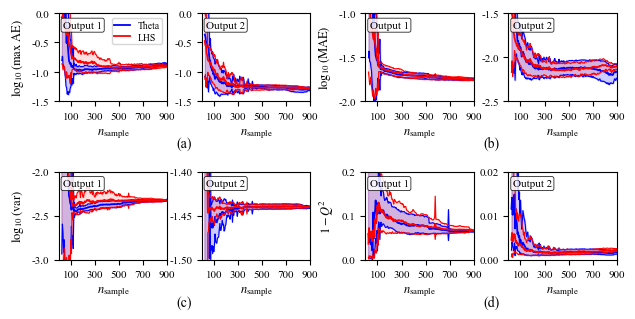

In [9]:
## Plotting

import numpy as np
import matplotlib.pyplot as plt

from matplotlib.gridspec import (
    GridSpec,
    GridSpecFromSubplotSpec,
)

set_plot_style()

try:
    var_true_global = np.asarray(
        var_true_global,
        dtype=float,
    )
except NameError:
    var_true_global = None

theta_color = "blue"
lhs_color = "red"

theta_label = "Theta"
lhs_label = "LHS"

xmax = 900
xticks = [100, 300, 500, 700, 900]

fig = plt.figure(figsize=(7.2, 3.2))

outer_gs = GridSpec(
    2,
    2,
    figure=fig,
    wspace=0.22,
    hspace=0.80,
)

axes = np.empty((4, 2), dtype=object)

for g in range(4):
    outer_r = g // 2
    outer_c = g % 2

    inner_gs = GridSpecFromSubplotSpec(
        1,
        2,
        subplot_spec=outer_gs[outer_r, outer_c],
        wspace=0.32,
    )

    for out in range(2):
        axes[g, out] = fig.add_subplot(
            inner_gs[0, out]
        )

loo_data = prepare_loo_curves(results)

# (a) MaxAE
plot_log_metric_group(
    axes=axes,
    results=results,
    group_id=0,
    metric_key="max_ae_hist",
    ylabel=r"$\log_{10}(\mathrm{max\ AE})$",
    ylims=[
        (-1.5, 0.0),
        (-1.5, 0.0),
    ],
    yticks=[
        [-1.5, -1.0, -0.5, 0.0],
        [-1.5, -1.0, -0.5, 0.0],
    ],
    theta_color=theta_color,
    lhs_color=lhs_color,
    theta_label=theta_label,
    lhs_label=lhs_label,
    xticks=xticks,
    xmax=xmax,
    add_legend_labels=True,
)

# (b) MAE
plot_log_metric_group(
    axes=axes,
    results=results,
    group_id=1,
    metric_key="mae_hist",
    ylabel=r"$\log_{10}(\mathrm{MAE})$",
    ylims=[
        (-2.0, -1.0),
        (-2.5, -1.5),
    ],
    yticks=[
        [-2.0, -1.5, -1.0],
        [-2.5, -2.0, -1.5],
    ],
    theta_color=theta_color,
    lhs_color=lhs_color,
    theta_label=theta_label,
    lhs_label=lhs_label,
    xticks=xticks,
    xmax=xmax,
)

# (c) Variance
plot_log_metric_group(
    axes=axes,
    results=results,
    group_id=2,
    metric_key="eps_hist",
    ylabel=r"$\log_{10}(\mathrm{var})$",
    ylims=[
        (-3.0, -2.0),
        (-1.50, -1.40),
    ],
    yticks=[
        [-3.0, -2.5, -2.0],
        [-1.50, -1.45, -1.40],
    ],
    theta_color=theta_color,
    lhs_color=lhs_color,
    theta_label=theta_label,
    lhs_label=lhs_label,
    xticks=xticks,
    xmax=xmax,
    var_true_global=var_true_global,
    add_variance_reference=False,
)

# (d) LOO
plot_loo_group(
    axes=axes,
    loo_data=loo_data,
    group_id=3,
    theta_color=theta_color,
    lhs_color=lhs_color,
    xticks=xticks,
    xmax=xmax,
    ylims=[
        (0.0, 2.0e-1),
        (0.0, 2.0e-2),
    ],
    yticks=[
        [0.0, 0.1, 0.2],
        [0.0, 0.01, 0.02],
    ],
)

handles, labels = (
    axes[0, 0].get_legend_handles_labels()
)

axes[0, 0].legend(
    handles,
    labels,
    loc="best",
    frameon=True,
    labelspacing=0.15,
    handlelength=1.6,
    borderpad=0.25,
    fontsize=7,
)

panel_labels = ["(a)", "(b)", "(c)", "(d)"]

panel_y_offset_toprow = 0.11
panel_y_offset_bottomrow = 0.11

for g, label in enumerate(panel_labels):
    x0 = axes[g, 0].get_position().x0
    x1 = axes[g, 1].get_position().x1

    y0 = min(
        axes[g, 0].get_position().y0,
        axes[g, 1].get_position().y0,
    )

    if g in [0, 1]:
        y_offset = panel_y_offset_toprow
    else:
        y_offset = panel_y_offset_bottomrow

    fig.text(
        0.5 * (x0 + x1),
        y0 - y_offset,
        label,
        ha="center",
        va="top",
        fontsize=10,
    )

plt.savefig(
    "combined_metric_groups.pdf",
    format="pdf",
    bbox_inches="tight",
)

plt.show()